<a href="https://colab.research.google.com/github/Ashithrai507/cloud_comp/blob/main/test_bac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics opencv-python --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.7 MB/s eta 0:00:00


✅ Model loaded successfully!

image 1/1 /content/drive/MyDrive/mini_bacteeria/batch1/Campylobacter.v2i.yolov8/test/images/Campylobacter-48-_png.rf.8a01c7e041f95b6fe87a0af9411b0c9e.jpg: 512x640 1 Staphylococcus - v2 2024-08-28 7-05am, 62.9ms
Speed: 2.5ms preprocess, 62.9ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 640)

🧫 Total Bacteria Detected: 1
🧬 Total Colonies: N/A (Microscopic count not measurable)
🌡️ Total Coverage: 0.91%
✅ Result saved as: /content/drive/MyDrive/mini_bacteeria/batch1/Campylobacter.v2i.yolov8/test/images/Campylobacter-48-_png.rf.8a01c7e041f95b6fe87a0af9411b0c9e_analyzed.jpg


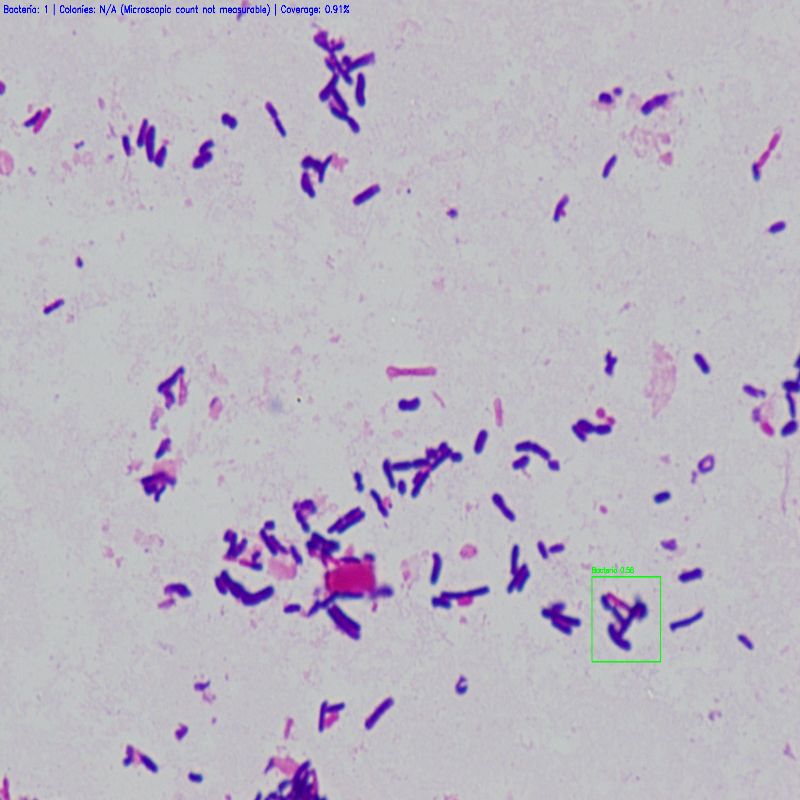

In [5]:


from ultralytics import YOLO
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

model_path = "/content/drive/MyDrive/Staphylococcus_model.pt"  # 🔹 Change this path
model = YOLO(model_path)
print("✅ Model loaded successfully!")

# --- Step 2: Provide the image path you want to test ---
image_path = "/content/drive/MyDrive/mini_bacteeria/batch1/Campylobacter.v2i.yolov8/test/images/Campylobacter-48-_png.rf.8a01c7e041f95b6fe87a0af9411b0c9e.jpg"  # 🔹 Change this path

# --- Step 3: Read and check image ---
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"❌ Cannot read image: {image_path}")

# --- Step 4: Run model prediction ---
results = model(image_path, conf=0.5)
detections = results[0]

# --- Step 5: Extract bounding boxes ---
boxes = detections.boxes.xyxy.cpu().numpy() if detections.boxes is not None else []
scores = detections.boxes.conf.cpu().numpy() if detections.boxes is not None else []

# --- Step 6: Compute statistics ---
total_bacteria = len(boxes)
total_colonies = "N/A (Microscopic count not measurable)"
img_area = img.shape[0] * img.shape[1]
colony_area = sum([(x2 - x1) * (y2 - y1) for x1, y1, x2, y2 in boxes])
coverage_percent = (colony_area / img_area) * 100 if img_area > 0 else 0

print(f"\n🧫 Total Bacteria Detected: {total_bacteria}")
print(f"🧬 Total Colonies: {total_colonies}")
print(f"🌡️ Total Coverage: {coverage_percent:.2f}%")

# --- Step 7: Draw bounding boxes ---
for box, score in zip(boxes, scores):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img, f"Bacteria {score:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# --- Step 8: Add summary text ---
text_summary = f"Bacteria: {total_bacteria} | Colonies: {total_colonies} | Coverage: {coverage_percent:.2f}%"
cv2.putText(img, text_summary, (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

output_path = os.path.splitext(image_path)[0] + "_analyzed.jpg"
cv2.imwrite(output_path, img)
print(f"✅ Result saved as: {output_path}")

resized = cv2.resize(img, (800, 800))
cv2_imshow(resized)


🔄 Loading trained model...
✅ Model loaded successfully!
📸 Enter image path: /content/drive/MyDrive/bacterial.v1i.yolov8/test/images/img1.jpg

image 1/1 /content/drive/MyDrive/bacterial.v1i.yolov8/test/images/img1.jpg: 640x640 25 e_colis, 9.4ms
Speed: 3.7ms preprocess, 9.4ms inference, 15.1ms postprocess per image at shape (1, 3, 640, 640)
🧫 Total Bacteria Detected: 25
🧬 Total Colonies: 25
🌡️ Total Coverage: 2.30%
✅ Result saved as: /content/drive/MyDrive/bacterial.v1i.yolov8/test/images/img1_analyzed.jpg


DisabledFunctionError: cv2.imshow() is disabled in Colab, because it causes Jupyter sessions
to crash; see https://github.com/jupyter/notebook/issues/3935.
As a substitution, consider using
  from google.colab.patches import cv2_imshow
